In [8]:
import matplotlib.pyplot as plt

class TuringMachine:
    def __init__(self, tape_string, blank_symbol, initial_state, accept_state, reject_state, transition_function):
        """
        tape_string: the initial input as a string (e.g., '010').
        blank_symbol: symbol used for blanks (e.g., '⊔' or '_').
        initial_state: the start state (e.g., 'q0').
        accept_state: the accept/halting state (e.g., 'ha').
        reject_state: the reject/halting state (e.g., 'hr').
        transition_function: dict with keys (state, symbol) and values (new_symbol, direction, new_state).
        """
        self.tape = {}
        for i, char in enumerate(tape_string):
            self.tape[i] = char
        
        self.blank_symbol = blank_symbol
        self.head = 0
        self.current_state = initial_state
        self.accept_state = accept_state
        self.reject_state = reject_state
        self.transition_function = transition_function

    def step(self):
        """
        Executes one transition step.
        Returns True if a valid transition was made; returns False if no transition is available (machine halts).
        """
        current_symbol = self.tape.get(self.head, self.blank_symbol)
        key = (self.current_state, current_symbol)
        
        if key in self.transition_function:
            new_symbol, direction, new_state = self.transition_function[key]
            
            # Write the new symbol
            self.tape[self.head] = new_symbol
            
            # Move the head
            if direction == 'R':
                self.head += 1
            elif direction == 'L':
                self.head -= 1
            # If direction == 'S', stay in place
            
            # Update state
            self.current_state = new_state
            return True
        else:
            # No valid transition -> halts
            return False

    def is_halted(self):
        """
        Checks if the machine is in either the accept or reject state.
        """
        return self.current_state == self.accept_state or self.current_state == self.reject_state


In [9]:
def record_configurations(tm, max_steps=50):
    """
    Runs the Turing machine up to max_steps or until it halts,
    returning a list of configurations for each step.
    """
    configurations = []
    
    # Record the initial configuration
    configurations.append((dict(tm.tape), tm.head, tm.current_state))
    
    for _ in range(max_steps):
        if tm.is_halted():
            break
        transitioned = tm.step()
        # Record the configuration after the step
        configurations.append((dict(tm.tape), tm.head, tm.current_state))
        
        if not transitioned or tm.is_halted():
            break
    
    return configurations


In [4]:
import matplotlib.pyplot as plt

def plot_configurations_separately(configs, blank_symbol='⊔', window=5):
    """
    Given a list of configurations (tape_dict, head, state),
    create a separate figure for each configuration.
    
    Each figure displays a segment of the tape (from head-window to head+window),
    an arrow marking the head position (drawn from below up to the cell),
    and the current state shown in a small labeled box below.
    
    Parameters:
      configs (list): List of tuples (tape_dict, head, state)
      blank_symbol (str): Symbol used for blank cells.
      window (int): Number of cells to display on either side of the head.
    """
    for tape_dict, head, state in configs:
        plt.figure(figsize=(8, 2))
        
        # Determine the range of tape cells to display.
        left = head - window
        right = head + window
        
        ax = plt.gca()  # Get current axis.
        
        # Draw each tape cell.
        for i in range(left, right + 1):
            symbol = tape_dict.get(i, blank_symbol)
            cell_rect = plt.Rectangle((i, 0), 1, 1, fill=False, edgecolor='black')
            ax.add_patch(cell_rect)
            ax.text(i + 0.5, 0.5, symbol, ha='center', va='center', fontsize=12)
        
        # Draw an arrow from below up to the head cell.
        ax.annotate("", 
                    xy=(head + 0.5, 0),         # tip of the arrow at the tape cell
                    xytext=(head + 0.5, -0.7),    # starting point below the tape
                    arrowprops=dict(arrowstyle="->", color='red', lw=1.5))
        
        # Display the current state in a labeled box below the arrow.
        ax.text(head + 0.5, -1.1, state,
                ha='center', va='center', fontsize=12,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))
        
        # Set the plot limits and remove axes.
        ax.set_xlim(left, right + 1)
        ax.set_ylim(-1.5, 1.5)
        ax.axis('off')
        
        plt.tight_layout()
        plt.show()


In [10]:
import matplotlib.pyplot as plt
from IPython.display import display

def plot_configuration_fixed(tape_dict, head, state, fixed_left, fixed_right, blank_symbol='⊔'):
    """
    Plots a single Turing Machine configuration with a fixed tape range.
    The tape cells remain in a fixed position and only the state pointer (arrow & label) moves.
    
    Parameters:
      tape_dict (dict): Mapping of tape indices to symbols.
      head (int): The current head position.
      state (str): The current state.
      fixed_left (int): The leftmost tape cell index to display.
      fixed_right (int): The rightmost tape cell index to display.
      blank_symbol (str): Symbol for blank cells.
    """
    fig, ax = plt.subplots(figsize=(8, 2))
    
    # Draw the fixed tape cells.
    for i in range(fixed_left, fixed_right + 1):
        symbol = tape_dict.get(i, blank_symbol)
        cell_rect = plt.Rectangle((i, 0), 1, 1, fill=False, edgecolor='black')
        ax.add_patch(cell_rect)
        ax.text(i + 0.5, 0.5, symbol, ha='center', va='center', fontsize=12)
    
    # Draw an arrow pointing from below the tape up to the cell with the head.
    ax.annotate("",
                xy=(head + 0.5, 0),         # tip of the arrow at the tape cell
                xytext=(head + 0.5, -0.7),    # starting point below the tape
                arrowprops=dict(arrowstyle="->", color='red', lw=1.5))
    
    # Draw the state label below the arrow in a box.
    ax.text(head + 0.5, -1.1, state,
            ha='center', va='center', fontsize=12,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))
    
    ax.set_xlim(fixed_left, fixed_right + 1)
    ax.set_ylim(-1.5, 1.5)
    ax.axis('off')
    plt.tight_layout()
    
    # Use display to force the figure to show in the notebook, then close it.
    display(fig)
    plt.close(fig)


def plot_all_configurations_individually_fixed(configs, fixed_left, fixed_right, blank_symbol='⊔'):
    """
    Iterates through a list of configurations and plots each one as its own figure,
    using a fixed tape range for every configuration.
    
    Parameters:
      configs (list): List of tuples (tape_dict, head, state).
      fixed_left (int): The leftmost tape cell index to display.
      fixed_right (int): The rightmost tape cell index to display.
      blank_symbol (str): Symbol for blank cells.
    """
    for idx, (tape_dict, head, state) in enumerate(configs):
        print(f"Transition {idx}:")
        plot_configuration_fixed(tape_dict, head, state, fixed_left, fixed_right, blank_symbol)


In [11]:
def record_configurations(tm, max_steps=50):
    configurations = []
    # Record the initial configuration.
    configurations.append((dict(tm.tape), tm.head, tm.current_state))
    
    for _ in range(max_steps):
        if tm.is_halted():
            break
        if not tm.step():
            break
        configurations.append((dict(tm.tape), tm.head, tm.current_state))
    
    return configurations


Transition 0:


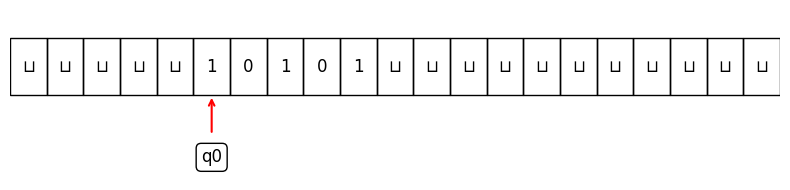

Transition 1:


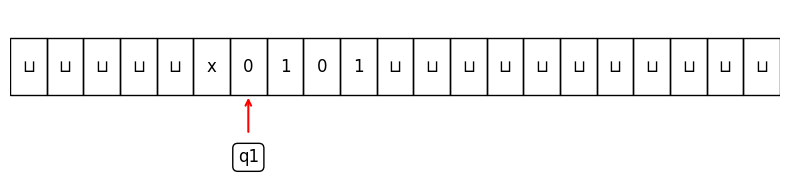

Transition 2:


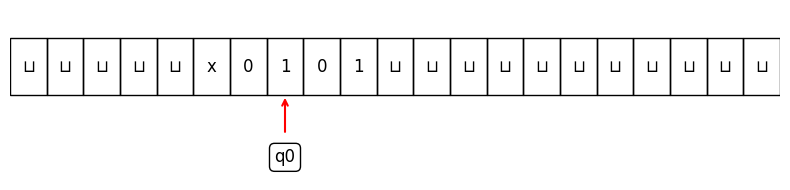

Transition 3:


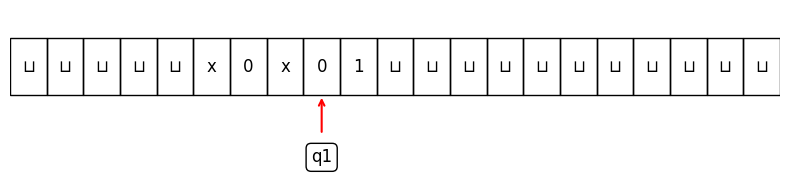

Transition 4:


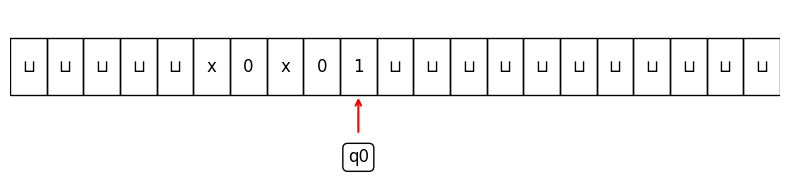

Transition 5:


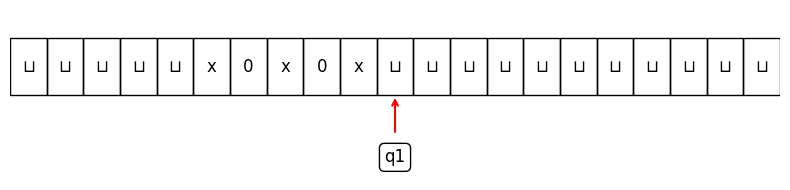

Transition 6:


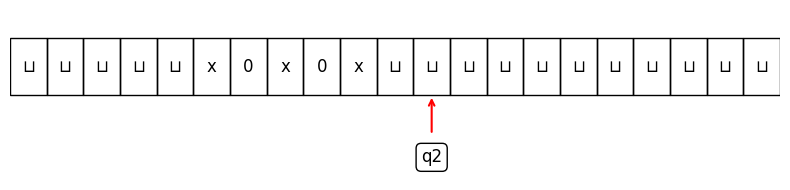

In [ ]:
transition_function = {
    # In state q0, on '0' or '1' we mark the cell with 'x' and move to q1.
    ('q0', '0'): ('x', 'R', 'q1'),
    ('q0', '1'): ('x', 'R', 'q1'),
    # In state q0, if a blank is encountered, go to the halting state q2.
    ('q0', '⊔'): ('⊔', 'R', 'q2'),

    # In state q1, on '0' or '1' we leave the symbol unchanged, move right, and return to q0.
    ('q1', '0'): ('0', 'R', 'q0'),
    ('q1', '1'): ('1', 'R', 'q0'),
    # In state q1, if a blank is encountered, transition to the halting state q2.
    ('q1', '⊔'): ('⊔', 'R', 'q2')
}

# Example: Creating a Turing machine instance using the above transition function.
# We'll assume the TuringMachine class is defined as in the previous cells.
tm = TuringMachine(
    tape_string="10101",      # Input tape; adjust as needed.
    blank_symbol='⊔',
    initial_state='q0',
    accept_state='q2',        # q2 is the halting (accept) state.
    reject_state='qr',        # For example, 'qr' could be a reject state (unused here).
    transition_function=transition_function
)

# Assume 'tm' is an instance of your TuringMachine class.
configs = record_configurations(tm, max_steps=10)
plot_all_configurations_individually_fixed(configs, fixed_left=-5, fixed_right=15, blank_symbol='⊔')


In [14]:
def create_transition_plots(configs, fixed_left, fixed_right, blank_symbol='⊔'):
    """
    Given a list of configurations (tape_dict, head, state),
    create a plot (matplotlib figure) for each configuration and return a list of figures.
    """
    plots = []
    for idx, (tape_dict, head, state) in enumerate(configs):
        fig, ax = plt.subplots(figsize=(8, 2))
        # Draw fixed tape cells.
        for i in range(fixed_left, fixed_right + 1):
            symbol = tape_dict.get(i, blank_symbol)
            cell_rect = plt.Rectangle((i, 0), 1, 1, fill=False, edgecolor='black')
            ax.add_patch(cell_rect)
            ax.text(i + 0.5, 0.5, symbol, ha='center', va='center', fontsize=12)
        # Draw an arrow pointing to the head cell.
        ax.annotate("",
                    xy=(head + 0.5, 0),
                    xytext=(head + 0.5, -0.7),
                    arrowprops=dict(arrowstyle="->", color='red', lw=1.5))
        # Display the state label below the arrow.
        ax.text(head + 0.5, -1.1, state,
                ha='center', va='center', fontsize=12,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))
        ax.set_xlim(fixed_left, fixed_right + 1)
        ax.set_ylim(-1.5, 1.5)
        ax.axis('off')
        plt.tight_layout()
        plots.append(fig)
    return plots